# **Installs**

In [ ]:
!pip install neuralforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.0/261.0 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.8/285.8 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.1/70.1 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip install kaggle

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
!kaggle competitions download -c walmart-recruiting-store-sales-forecasting
!unzip walmart-recruiting-store-sales-forecasting

#unzip
!unzip train.csv.zip
!unzip test.csv.zip
!unzip features.csv.zip

#remove whats not needed anymore
!rm train.csv.zip
!rm test.csv.zip
!rm features.csv.zip
!rm walmart-recruiting-store-sales-forecasting.zip

  0% 0.00/2.70M [00:00<?, ?B/s]
100% 2.70M/2.70M [00:00<00:00, 703MB/s]
Archive:  walmart-recruiting-store-sales-forecasting.zip
  inflating: features.csv.zip        
  inflating: sampleSubmission.csv.zip  
  inflating: stores.csv              
  inflating: test.csv.zip            
  inflating: train.csv.zip           
Archive:  train.csv.zip
  inflating: train.csv               
Archive:  test.csv.zip
  inflating: test.csv                
Archive:  features.csv.zip
  inflating: features.csv            


In [ ]:
!pip install wandb onnx -Uq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 103.3 MB/s eta 0:00:00


# **Imports**

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import torch
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score, GridSearchCV
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS
from neuralforecast.losses.pytorch import MAE


In [ ]:
import wandb
wandb.login()

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: gchit21 (arazm21-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
stores_df = pd.read_csv("stores.csv")
features_df =pd.read_csv("features.csv")
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 10)

train_df["Date"] = pd.to_datetime(train_df["Date"])
features_df["Date"] = pd.to_datetime(features_df["Date"])

df = train_df.merge(features_df, on=["Store", "Date", "IsHoliday"], how="left")
df = df.merge(stores_df, on="Store", how="left")
df = df.sort_values("Date").reset_index(drop=True)


In [ ]:
df

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,29,5,2010-02-05,15552.08,False,24.36,2.788,NaN,NaN,NaN,NaN,NaN,131.527903,10.064,B,93638
2,29,6,2010-02-05,3200.22,False,24.36,2.788,NaN,NaN,NaN,NaN,NaN,131.527903,10.064,B,93638
3,29,7,2010-02-05,10820.05,False,24.36,2.788,NaN,NaN,NaN,NaN,NaN,131.527903,10.064,B,93638
4,29,8,2010-02-05,20055.64,False,24.36,2.788,NaN,NaN,NaN,NaN,NaN,131.527903,10.064,B,93638
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,40,87,2012-10-26,24638.96,False,49.65,3.917,3605.71,55.98,0.28,486.81,1389.06,138.728161,4.145,A,155083
421566,19,30,2012-10-26,3740.12,False,56.49,4.071,5430.75,90.07,NaN,904.34,1665.77,138.728161,7.992,A,203819
421567,19,31,2012-10-26,3128.17,False,56.49,4.071,5430.75,90.07,NaN,904.34,1665.77,138.728161,7.992,A,203819
421568,19,33,2012-10-26,5740.14,False,56.49,4.071,5430.75,90.07,NaN,904.34,1665.77,138.728161,7.992,A,203819


In [ ]:
df['MarkDown1'].isna().mean()

np.float64(0.6425718148824632)

In [ ]:
df['MarkDown2'].isna().mean()

np.float64(0.7361102545247528)

In [ ]:
df['MarkDown3'].isna().mean()

np.float64(0.6748084541120098)

In [ ]:
df['MarkDown4'].isna().mean()

np.float64(0.6798467632896079)

In [ ]:
df['MarkDown1'].mode()

np.float64(7246.420195910566)

In [ ]:
df["TotalMarkDown"] = df['MarkDown1'].fillna(df['MarkDown1'].mode()) + df['MarkDown2'].fillna(df['MarkDown2'].mode()) + df['MarkDown3'].fillna(df['MarkDown3'].mode()) + df['MarkDown4'].fillna(df['MarkDown4'].mode()) + df['MarkDown5'].fillna(df['MarkDown5'].mode())

In [ ]:
df["TotalMarkDown"].mean()

np.float64(5021.269049932396)

In [ ]:
features_df

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8185,45,2013-06-28,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,False
8186,45,2013-07-05,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,False
8187,45,2013-07-12,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,False
8188,45,2013-07-19,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,False


In [ ]:
stores_df["Type"]

,Type
0,A
1,A
2,B
3,A
4,B
...,...
40,A
41,C
42,C
43,C


# **Data Exploration**

**Total Sales**

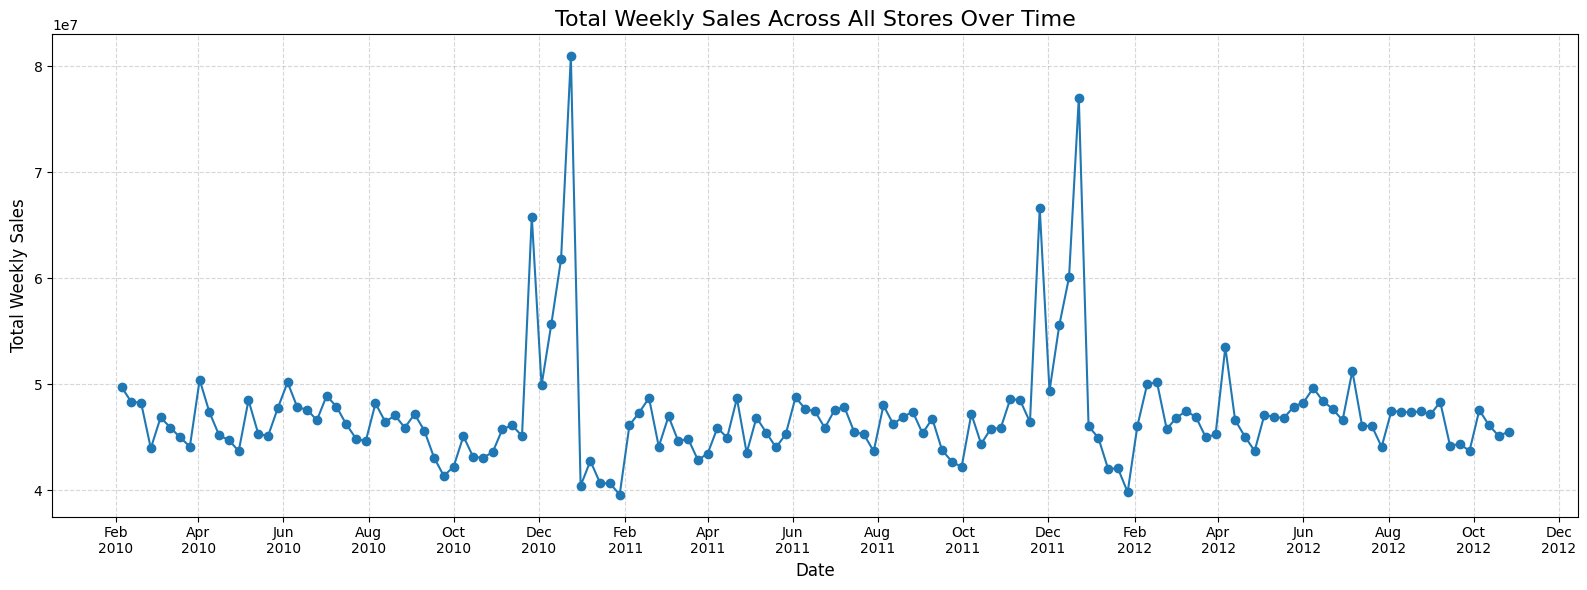

In [ ]:
total_sales_per_date = train_df.groupby("Date")["Weekly_Sales"].sum().reset_index()
total_sales_per_date = total_sales_per_date.sort_values("Date")

total_sales_per_date["Date"] = pd.to_datetime(total_sales_per_date["Date"])


plt.figure(figsize=(16, 6))
plt.plot(total_sales_per_date["Date"], total_sales_per_date["Weekly_Sales"], marker='o', linestyle='-')


plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

plt.title("Total Weekly Sales Across All Stores Over Time", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Weekly Sales", fontsize=12)
plt.grid(True, which='major', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()



**Sales per Store**

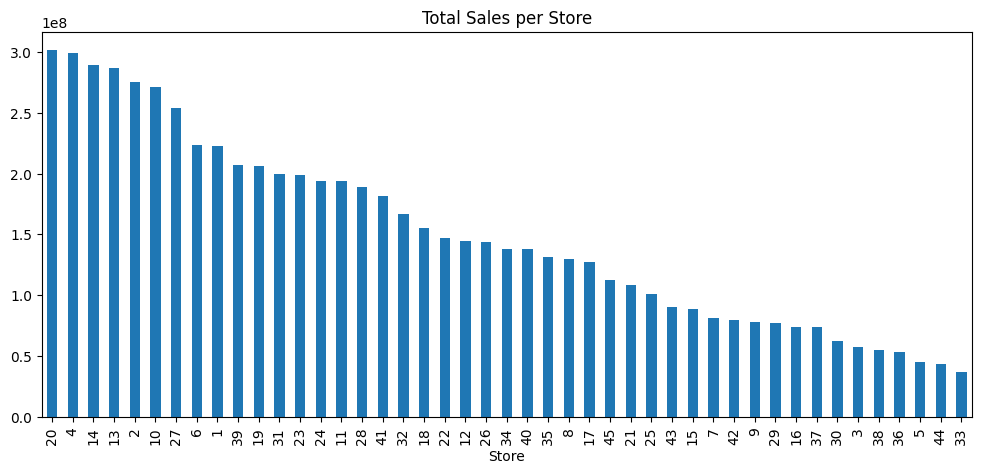

In [ ]:
store_sales = train_df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)
store_sales.plot(kind='bar', figsize=(12, 5), title='Total Sales per Store')
plt.show()


**Sales per Department**

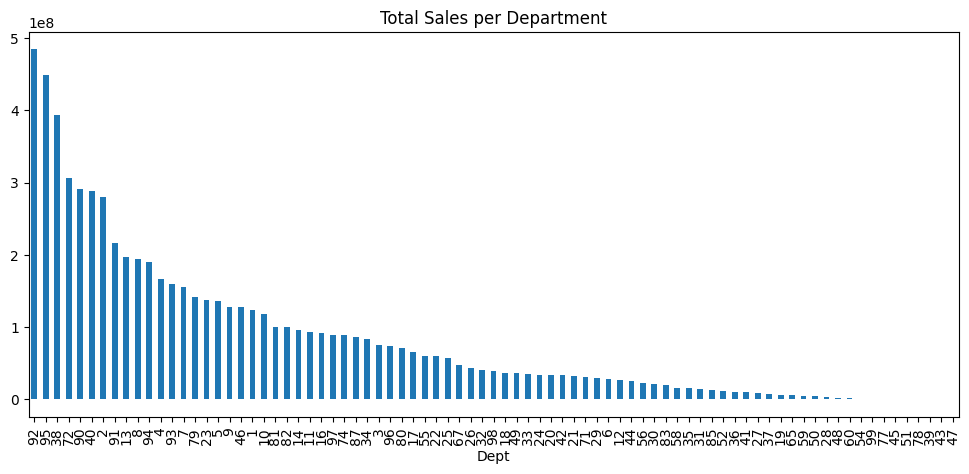

In [ ]:
dept_sales = train_df.groupby('Dept')['Weekly_Sales'].sum().sort_values(ascending=False)
dept_sales.plot(kind='bar', figsize=(12, 5), title='Total Sales per Department')
plt.show()


**Total Sales for each Type of Store**

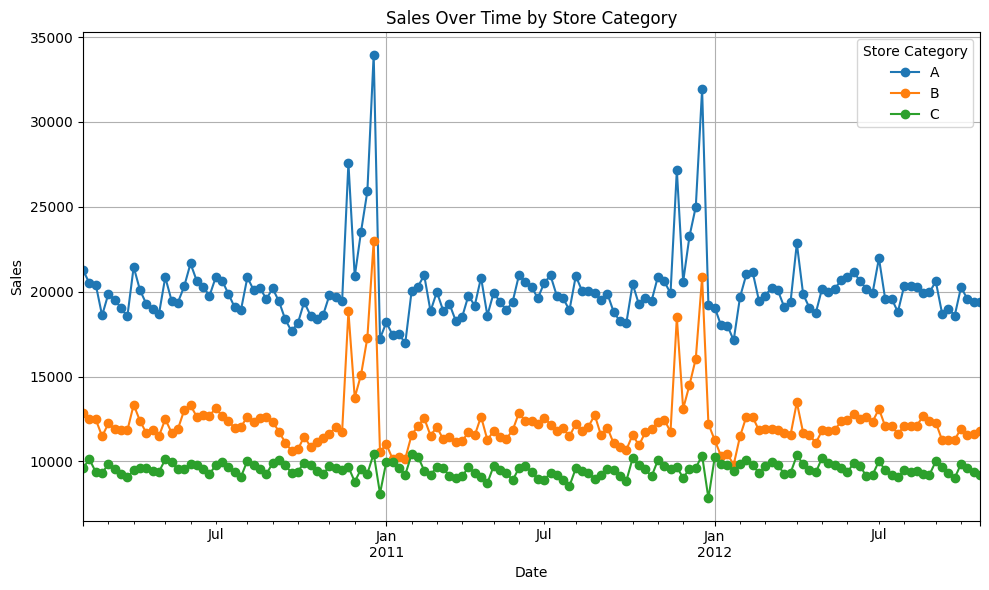

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

# Pivot to reshape: rows = dates, columns = categories
pivot_df = df.pivot_table(index='Date', columns='Type', values='Weekly_Sales')

# Plot
pivot_df.plot(marker='o', figsize=(10, 6))
plt.title('Sales Over Time by Store Category')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)
plt.legend(title='Store Category')
plt.tight_layout()
plt.show()


In [ ]:
stores_df['Type'].value_counts()

,count
Type,
A,22
B,17
C,6


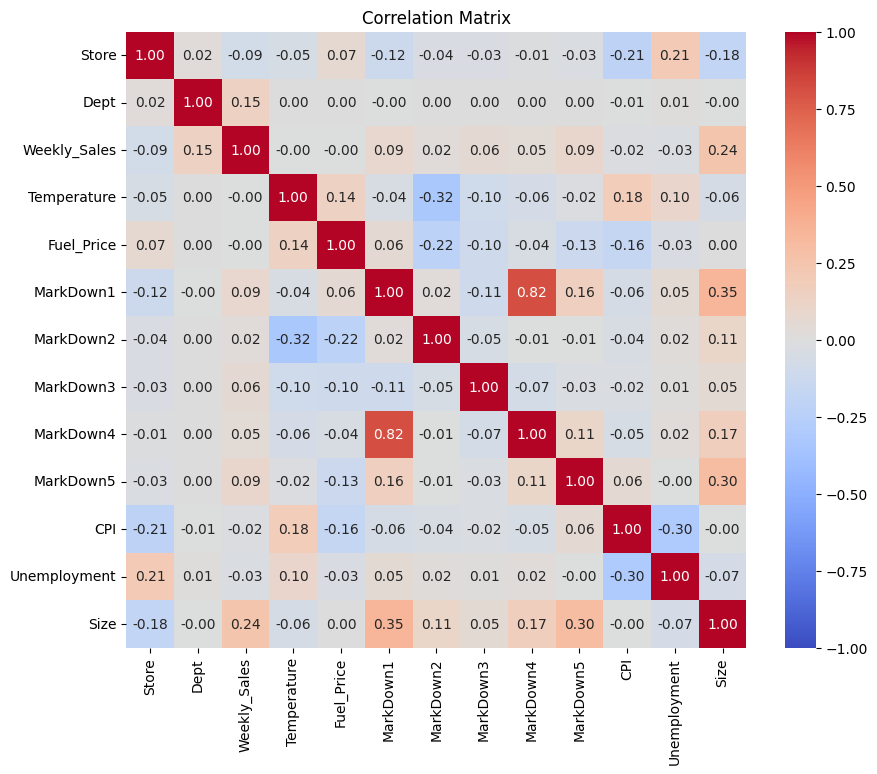

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns
numeric_cols = df.select_dtypes(include='number').columns

# Compute correlation matrix
corr_matrix = df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()


In [ ]:
df[['MarkDown2', 'Weekly_Sales']].corr()


,MarkDown2,Weekly_Sales
MarkDown2,1.00000,0.02413
Weekly_Sales,0.02413,1.00000


In [ ]:
df

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,TotalMarkDown
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315,2758.59
1,29,5,2010-02-05,15552.08,False,24.36,2.788,NaN,NaN,NaN,NaN,NaN,131.527903,10.064,B,93638,NaN
2,29,6,2010-02-05,3200.22,False,24.36,2.788,NaN,NaN,NaN,NaN,NaN,131.527903,10.064,B,93638,NaN
3,29,7,2010-02-05,10820.05,False,24.36,2.788,NaN,NaN,NaN,NaN,NaN,131.527903,10.064,B,93638,NaN
4,29,8,2010-02-05,20055.64,False,24.36,2.788,NaN,NaN,NaN,NaN,NaN,131.527903,10.064,B,93638,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,40,87,2012-10-26,24638.96,False,49.65,3.917,3605.71,55.98,0.28,486.81,1389.06,138.728161,4.145,A,155083,5537.84
421566,19,30,2012-10-26,3740.12,False,56.49,4.071,5430.75,90.07,NaN,904.34,1665.77,138.728161,7.992,A,203819,NaN
421567,19,31,2012-10-26,3128.17,False,56.49,4.071,5430.75,90.07,NaN,904.34,1665.77,138.728161,7.992,A,203819,NaN
421568,19,33,2012-10-26,5740.14,False,56.49,4.071,5430.75,90.07,NaN,904.34,1665.77,138.728161,7.992,A,203819,NaN


# **Functions**

In [ ]:
def prepare_df_for_nf(df: pd.DataFrame, is_train: bool = True) -> pd.DataFrame:
    df_pre = df.copy()
    # Convert Date to datetime and rename to ds
    df_pre['Date'] = pd.to_datetime(df_pre['Date'])
    df_pre.rename(columns={'Date': 'ds'}, inplace=True)

    # Rename Weekly_Sales to y in training; create dummy y in test
    if is_train:
        df_pre.rename(columns={'Weekly_Sales': 'y'}, inplace=True)
    else:
        df_pre['y'] = np.nan

    # Build unique_id per Store-Dept
    df_pre['unique_id'] = (
        df_pre['Dept'].astype(str) + '_' + df_pre['Store'].astype(str)
    )

    return df_pre

In [ ]:
def split_sales_data(df: pd.DataFrame, split_date : pd.Timestamp = pd.Timestamp('2012-02-15')):
    """
    Splits sales data into train and test sets based on a provided date,
    including the 'Weekly_Sales' column in both dataframes.

    Parameters:
    - df (pd.DataFrame): df to be split.
    - split_date (pd.Timestamp): The cutoff date for train-test split.

    Returns:
    - df_train, df_test: Tuple of training and test dataframes including 'Weekly_Sales'.
    """
    # Ensure Date is in datetime format
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'])

    train_mask = df['Date'] < split_date
    test_mask = df['Date'] >= split_date

    df_train = df[train_mask].copy()
    df_test = df[test_mask].copy()

    return df_train, df_test

In [ ]:
 # WMAE calculation
def wmae(y_true, y_pred, w):
    """Weighted MAE (holidays count 5×) with NaN handling."""
    # Create mask for finite values
    mask = np.isfinite(y_true) & np.isfinite(y_pred) & np.isfinite(w)

    if not mask.any():
        print("⚠️ All values are NaN/infinite in WMAE calculation")
        return np.nan

    # Filter to finite values only
    y_true_clean = y_true[mask]
    y_pred_clean = y_pred[mask]
    w_clean = w[mask]

    if w_clean.sum() == 0:
        print("⚠️ Sum of weights is zero in WMAE calculation")
        return np.nan

    return (w_clean * np.abs(y_true_clean - y_pred_clean)).sum() / w_clean.sum()

In [ ]:
def log_params(model, static_vars: list, dynamic_vars: list):
    """
    Log DLinear hyperparameters and feature lists to W&B.
    Only logs attributes if they exist on the model.
    """
    cfg = {}

    # List of attributes we know DLinear should have
    for attr in [
        "h",
        "input_size",
        "learning_rate",
        "max_steps",
        "bach_size",
        "stack_type",
        "n_blocks",
    ]:
        val = getattr(model, attr, None)
        if val is not None:
            cfg[attr] = val

    # Log loss name if available
    loss = getattr(model, "loss", None)
    if loss is not None:
        cfg["loss"] = loss.__class__.__name__

    # Add your feature lists
    cfg["static_vars"]  = static_vars
    cfg["dynamic_vars"] = dynamic_vars

    # Update W&B config
    wandb.config.update(cfg, allow_val_change=True)

In [ ]:
def log_wandb(nf, train_df, val_df, y_val, w_val, split="val"):
    """
    1) Forecast with nf.predict on train_df
    2) Align forecasts to val_df by unique_id and position
    3) Compute MAE, RMSE, WMAE
    4) Log metrics + diagnostic plots to W&B
    """
    # 1) Forecast
    preds_all = nf.predict(df=train_df)

    # 2) Align by mask + positional slicing
    records = []
    for uid in preds_all['unique_id'].unique():
        p = preds_all[preds_all['unique_id'] == uid].sort_values('ds').reset_index(drop=True)
        v = val_df[val_df['unique_id'] == uid].sort_values('ds').reset_index(drop=True)
        if p.empty or v.empty:
            continue
        n = min(len(p), len(v))

        # Create boolean mask over val_df for this uid
        mask = (val_df['unique_id'] == uid).values
        # Extract the first n true values
        y_arr = y_val.values[mask][:n]
        w_arr = w_val[mask][:n]
        ds_arr = v['ds'].iloc[:n].values
        y_pred_arr = p['NBEATS'].iloc[:n].values

        # Build temp DataFrame
        records.append(pd.DataFrame({
            'unique_id': uid,
            'ds':         ds_arr,
            'y_true':     y_arr,
            'y_pred':     y_pred_arr,
            'w':          w_arr
        }))

    if not records:
        raise ValueError("No overlapping series for validation.")
    results = pd.concat(records, ignore_index=True)

    # 3) Metrics
    mae  = mean_absolute_error(results['y_true'], results['y_pred'])
    rmse = np.sqrt(mean_squared_error(results['y_true'], results['y_pred']))
    wmae = (results['w'] * np.abs(results['y_true'] - results['y_pred'])).sum() / results['w'].sum()

    wandb.log({f"{split}/MAE": mae, f"{split}/RMSE": rmse, f"{split}/WMAE": wmae})
    print(f"[{split.upper()}] MAE={mae:.4f}  RMSE={rmse:.4f}  WMAE={wmae:.4f}")

    mask_finite = np.isfinite(results['y_true']) & np.isfinite(results['y_pred'])

    # 4a) Actual vs Predicted
    fig, ax = plt.subplots(figsize=(6,6))
    ax.scatter(results.loc[mask_finite,'y_true'], results.loc[mask_finite,'y_pred'],
               alpha=0.3, s=10)
    mn, mx = results.loc[mask_finite, ['y_true','y_pred']].min().min(), \
             results.loc[mask_finite, ['y_true','y_pred']].max().max()
    ax.plot([mn,mx],[mn,mx],'r--', linewidth=1)
    ax.set(xlabel="Actual", ylabel="Predicted", title=f"{split.capitalize()} Actual vs Pred")
    wandb.log({f"{split}/actual_vs_pred": wandb.Image(fig)})
    plt.close(fig)

    # 4b) Residuals vs Predicted
    fig, ax = plt.subplots(figsize=(6,4))
    residuals = results['y_true'] - results['y_pred']
    ax.scatter(results.loc[mask_finite,'y_pred'], residuals[mask_finite], alpha=0.3, s=10)
    ax.hlines(0, results.loc[mask_finite,'y_pred'].min(),
                 results.loc[mask_finite,'y_pred'].max(), 'r', '--')
    ax.set(xlabel="Predicted", ylabel="Residuals", title=f"{split.capitalize()} Residuals")
    wandb.log({f"{split}/residuals": wandb.Image(fig)})
    plt.close(fig)

    # 4c) WMAE Error Distribution
    fig, ax = plt.subplots(figsize=(6,4))
    errors = results['w'] * np.abs(results['y_true'] - results['y_pred'])
    ax.hist(errors, bins=50, density=True, alpha=0.7)
    ax.set(xlabel="Weighted Abs Error", ylabel="Density", title=f"{split.capitalize()} WMAE Dist")
    wandb.log({f"{split}/wmae_error_dist": wandb.Image(fig)})
    plt.close(fig)

    # 4e) Total Weekly Sales Over Time (Actual vs Predicted)
    totals = results.groupby('ds')[['y_true', 'y_pred']].sum().reset_index()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(totals['ds'], totals['y_true'], label="Total Actual Sales", linewidth=2)
    ax.plot(totals['ds'], totals['y_pred'], label="Total Predicted Sales", linestyle='--', linewidth=2)

    ax.set_title(f"{split.capitalize()} Total Weekly Sales: Actual vs Predicted")
    ax.set_xlabel("Date")
    ax.set_ylabel("Total Weekly Sales")
    ax.legend()

    wandb.log({f"{split}/total_weekly_sales": wandb.Image(fig)})
    plt.close(fig)


    return {'MAE': mae, 'RMSE': rmse, 'WMAE': wmae}

# **Custom Classes**

**Merge features.csv and stores.csv**

In [ ]:
class BaseMerger(BaseEstimator, TransformerMixin):
    def __init__(self, features, stores):
        self.feature_store = features.merge(stores, how='inner', on='Store')
        self.feature_store['Date'] = pd.to_datetime(self.feature_store['Date'])

    def fit(self, X, y=None): return self

    def transform(self, X):
        X = X.copy()
        X['Date'] = pd.to_datetime(X['Date'])
        merged = X.merge(self.feature_store, how='left', on=['Store', 'Date', 'IsHoliday'])
        merged = merged.sort_values(by=['Store', 'Dept', 'Date']).reset_index(drop=True)
        return merged

**Encode Store types (A,B,C) to (3,2,1)**

In [ ]:
class CategoricalEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.type_mapping = {'A': 3, 'B': 2, 'C': 1}
        self.holiday_mapping = {False: 0, True: 1}

    def fit(self, X, y=None): return self

    def transform(self, X):
        X = X.copy()
        if 'Type' in X.columns:
            X['Type'] = X['Type'].map(self.type_mapping)
        if 'IsHoliday' in X.columns:
            X['IsHoliday'] = X['IsHoliday'].map(self.holiday_mapping)
        return X

**For CPI and Unemployment use moving window to fillna**

In [ ]:
class RollingWindowImputer(BaseEstimator, TransformerMixin):
    def __init__(self, window=4):
        self.window = window

    def fit(self, X, y=None):
        # No fitting needed
        return self

    def transform(self, df):
        data = df.copy()
        data['Date'] = pd.to_datetime(data['Date'])

        cols_to_impute = []
        if 'CPI' in data.columns:
            cols_to_impute.append('CPI')
        if 'Unemployment' in data.columns:
            cols_to_impute.append('Unemployment')
        if not cols_to_impute:
            return data

        group_key = ['Store'] if 'Store' in data.columns else []

        out_frames = []

        for _, group in data.groupby(group_key, as_index=False):
            block = group.sort_values('Date').copy()

            for col in cols_to_impute:
                # Rolling mean with window size self.window, centered
                rolling_mean = block[col].rolling(window=self.window, center=True, min_periods=1).mean()
                # Fill NaNs with the rolling mean values
                block[col] = block[col].fillna(rolling_mean)

            out_frames.append(block)

        return pd.concat(out_frames, ignore_index=True)


In [ ]:
class MarkdownModeImputerAndTotal(BaseEstimator, TransformerMixin):
    def __init__(self, markdown_cols=None):
        # Default columns if not specified
        if markdown_cols is None:
            self.markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
        else:
            self.markdown_cols = markdown_cols
        self.modes_ = {}

    def fit(self, X, y=None):
        # Compute modes for each markdown column
        for col in self.markdown_cols:
            if col in X.columns:
                mode_val = X[col].mode(dropna=True)
                self.modes_[col] = mode_val.iloc[0] if not mode_val.empty else 0
        return self

    def transform(self, X):
        df = X.copy()
        # Fill NaNs with mode for each markdown column
        for col in self.markdown_cols:
            if col in df.columns:
                df[col] = df[col].fillna(self.modes_.get(col, 0))
            else:
                # If column missing, create it filled with zeros
                df[col] = 0
        # Create TotalMarkdown as sum of markdown columns
        df['TotalMarkdown'] = df[self.markdown_cols].sum(axis=1)
        return df


In [ ]:
class EconomicFeatures(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()
        eps = 1e-5

        if 'CPI' in df.columns and 'Unemployment' in df.columns:
            cpi = df['CPI']
            unemp = df['Unemployment']

            df['economic_pressure'] = cpi * unemp
            df['purchasing_power'] = cpi / (unemp + eps)
            df['unemp_cpi_ratio'] = unemp / (cpi + eps)
            df['cpi_change'] = cpi.diff().fillna(0)
            df['unemp_change'] = unemp.diff().fillna(0)
            df['high_inflation'] = (cpi > 250).astype(int)
            df['high_unemployment'] = (unemp > 7).astype(int)

            # fuel_inflation_gap if Fuel_Price is available
            if 'Fuel_Price' in df.columns:
                df['fuel_inflation_gap'] = cpi - df['Fuel_Price']

            # store_economic_index if Size is available
            if 'Size' in df.columns:
                df['store_economic_index'] = (cpi + unemp) * df['Size']

        return df

In [ ]:
class StoreDeptAggregates(BaseEstimator, TransformerMixin):
    def __init__(self,
                 store_col='Store',
                 dept_col='Dept',
                 target_col='Weekly_Sales'):
        self.store_col = store_col
        self.dept_col = dept_col
        self.target_col = target_col

    def fit(self, X, y=None):
        # Store-level aggregates
        store_stats = X.groupby(self.store_col)[self.target_col].agg(['mean', 'median', 'std']).reset_index()
        store_stats.columns = [self.store_col,
                               'store_mean_sales',
                               'store_median_sales',
                               'store_std_sales']
        store_stats['store_std_sales'] = store_stats['store_std_sales'].fillna(0)
        self.store_stats_ = store_stats

        # Dept-level aggregates
        dept_stats = X.groupby(self.dept_col)[self.target_col].agg(['mean', 'std']).reset_index()
        dept_stats.columns = [self.dept_col,
                              'dept_mean_sales',
                              'dept_std_sales']
        dept_stats['dept_std_sales'] = dept_stats['dept_std_sales'].fillna(0)
        self.dept_stats_ = dept_stats

        # Store-Dept aggregates
        sd_stats = X.groupby([self.store_col, self.dept_col])[self.target_col].agg(['mean', 'std']).reset_index()
        sd_stats.columns = [self.store_col, self.dept_col,
                            'store_dept_mean_sales',
                            'store_dept_std_sales']
        sd_stats['store_dept_std_sales'] = sd_stats['store_dept_std_sales'].fillna(0)
        self.sd_stats_ = sd_stats

        return self


    def transform(self, X):
        X_ = X.copy()

        # Merge store stats
        X_ = X_.merge(self.store_stats_, on=self.store_col, how='left')
        # Merge dept stats
        X_ = X_.merge(self.dept_stats_, on=self.dept_col, how='left')
        # Merge store-dept stats
        X_ = X_.merge(self.sd_stats_, on=[self.store_col, self.dept_col], how='left')

        return X_


# **Run**

In [45]:
features = pd.read_csv('features.csv')
stores = pd.read_csv('stores.csv')
train = pd.read_csv('train.csv')
test=pd.read_csv('test.csv')

imputer = RollingWindowImputer()
features_wind = imputer.fit_transform(features)

cleaning_pipeline = Pipeline([
    ("merge",       BaseMerger(features_wind, stores)),
    ("fill_markdowns", MarkdownModeImputerAndTotal()),
    ("encode",      CategoricalEncoder())
])

agg = StoreDeptAggregates(store_col='Store', dept_col='Dept', target_col='Weekly_Sales')

features_pipeline = Pipeline([
    ("EconomicFeatures", EconomicFeatures()),
    ("aggregate",agg)

])



train_df_clean = cleaning_pipeline.fit_transform(train)
train_clean, val_clean = split_sales_data(train_df_clean)

train_featured = features_pipeline.fit_transform(train_clean)
val_featured = features_pipeline.fit_transform(val_clean)

train_formatted = prepare_df_for_nf(train_featured, True)
val_formatted = prepare_df_for_nf(val_featured, False)

y_val = val_formatted['Weekly_Sales']
val_formatted = val_formatted.drop(columns=["Weekly_Sales"])
y_train = train_formatted['y']
w_train = train_formatted['IsHoliday'].map({1:5,0:1}).values
w_val = val_formatted['IsHoliday'].map({1:5,0:1}).values

forecast_horizon = val_formatted.groupby('unique_id').size().iloc[0]

static_vars = [ 'Store', 'Dept', 'Type', 'Size','store_mean_sales',
                'store_median_sales','store_std_sales', 'dept_mean_sales', 'dept_std_sales',
                'store_dept_mean_sales', 'store_dept_std_sales'

              ]

dynamic_vars= [ 'IsHoliday' , 'Temperature' , 'Fuel_Price' , 'MarkDown1' , 'MarkDown2',
                'MarkDown3', 'MarkDown4', 'MarkDown5', 'MarkDownTotal','Unemployment',
                'CPI','economic_pressure','purchasing_power','unemp_cpi_ratio',
                'cpi_change','unemp_change','high_inflation','high_unemployment',
                'fuel_inflation_gap','store_economic_index',
              ]

static_df = train_formatted[['unique_id'] + static_vars].drop_duplicates().reset_index(drop=True)


In [44]:
train_formatted.columns

Index(['Store', 'Dept', 'ds', 'y', 'IsHoliday', 'Temperature', 'Fuel_Price',
       'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI',
       'Unemployment', 'Type', 'Size', 'TotalMarkdown', 'economic_pressure',
       'purchasing_power', 'unemp_cpi_ratio', 'cpi_change', 'unemp_change',
       'high_inflation', 'high_unemployment', 'fuel_inflation_gap',
       'store_economic_index', 'store_mean_sales', 'store_std_sales',
       'store_median_sales', 'dept_mean_sales', 'dept_std_sales',
       'dept_median_sales', 'sd_mean_sales', 'sd_std_sales', 'sd_median_sales',
       'unique_id'],
      dtype='object')

# **Train**

In [ ]:
wandb.init(project="ML_Final", name="NBEATS_train_simple_FeaturePipeline")

nbeats = NBEATS(
        h = forecast_horizon,
        input_size = 3,
        learning_rate=0.001,
        max_steps=1000,
        batch_size =32,
        stack_types=["identity","trend","seasonality"],
        n_blocks=[1,1,1],
        loss=MAE(),
        logger=True,
        enable_progress_bar=True,
        enable_model_summary=True,
        random_seed=42,
        )


nf = NeuralForecast(models=[nbeats], freq='W')

log_params(model=nbeats, static_vars=static_vars, dynamic_vars=dynamic_vars)

nf.fit(df=train_formatted,val_size=0)

val_metrics = log_wandb(nf,train_formatted,val_formatted,y_val,w_val,"val")



INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.5 M  | train
-------------------------------------------------------
2.5 M     Trainable params
3.0 K     Non-trainable params
2.5 M     Total params
9.882     Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

[VAL] MAE=3123.8620  RMSE=6431.0504  WMAE=3156.0926


# **Best Input_Size parameter search**

In [ ]:
input_sizes = [4, 8, 12, 16, 24, 36, 40, 48, 64 ,72, 96 ,102]
val_results_per_size = {}

for input_size in input_sizes:
    run_name = f"NBEATS_param_optim_inputSize:{input_size}"
    wandb.init(
        project="ML_Final",
        name=run_name,
        reinit=True,  # allow multiple in the same script
        config={"input_size": input_size}
    )

    nbeats = NBEATS(
        h = forecast_horizon,
        input_size = input_size,
        learning_rate=0.001,
        max_steps=1000,
        batch_size =32,
        stack_types=["identity","trend","seasonality"],
        n_blocks=[1,1,1],
        loss=MAE(),
        logger=True,
        enable_progress_bar=True,
        enable_model_summary=True,
        random_seed=42,
        )
    nf = NeuralForecast(models=[nbeats], freq='W')

    nf.fit(df=train_formatted, static_df=static_df, val_size=0)

    val_metrics = log_wandb(
        nf=nf,
        train_df=train_formatted,
        val_df=val_formatted,
        y_val=y_val,
        w_val=w_val,
        split="val"
     )

    val_results_per_size[input_size] = val_metrics['WMAE']

    wandb.finish()




INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.5 M  | train
-------------------------------------------------------
2.5 M     Trainable params
3.1 K     Non-trainable params
2.5 M     Total params
9.891     Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

[VAL] MAE=4443.3583  RMSE=9612.7560  WMAE=4488.6554


val/MAE,▁
val/RMSE,▁
val/WMAE,▁
val/MAE,4443.35832
val/RMSE,9612.75599
val/WMAE,4488.65536


# **Best Learning rate parameter search**

In [ ]:
lrs = [5e-2, 1e-2, 5e-3, 1e-3, 5e-4,  1e-4, 5e-5, 1e-5]
val_results_per_size = {}

for lr in lrs:
    run_name = f"NBEATS_param_optim_lr:{lr}"
    wandb.init(
        project="ML_Final",
        name=run_name,
        reinit=True,  # allow multiple in the same script
        config={"input_size": 36,
                "learning rate": lr,
                }
    )

    nbeats = NBEATS(
        h = forecast_horizon,
        input_size = 36 ,
        learning_rate=lr,
        max_steps=1000,
        batch_size =32,
        stack_types=["identity","trend","seasonality"],
        n_blocks=[1,1,1],
        loss=MAE(),
        logger=True,
        enable_progress_bar=True,
        enable_model_summary=True,
        random_seed=42,
        )
    nf = NeuralForecast(models=[nbeats], freq='W')

    nf.fit(df=train_formatted, static_df=static_df, val_size=0)

    val_metrics = log_wandb(
        nf=nf,
        train_df=train_formatted,
        val_df=val_formatted,
        y_val=y_val,
        w_val=w_val,
        split="val"
     )

    val_results_per_size[input_size] = val_metrics['WMAE']

    wandb.finish()

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.5 M  | train
-------------------------------------------------------
2.5 M     Trainable params
5.5 K     Non-trainable params
2.5 M     Total params
10.162    Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

[VAL] MAE=1832.0230  RMSE=4017.1094  WMAE=1833.4788


val/MAE,▁
val/RMSE,▁
val/WMAE,▁
val/MAE,1832.02295
val/RMSE,4017.10945
val/WMAE,1833.47878


# **Best Max_Steps parameter Search**

In [ ]:
max_stepss = [200, 400, 600, 800 ,1000, 1250, 1500, 1750,2000]
max_stepps_precise = [700,725,750,775]
max_stepps_precise2 = [825,850,875,900]
val_results_per_size = {}

for max_steps in max_stepps_precise2:
    run_name = f"NBEATS_param_optim_MaxSteps:{max_steps}"
    wandb.init(
        project="ML_Final",
        name=run_name,
        reinit=True,  # allow multiple in the same script
        config={"input_size": 36,
                "learning rate":0.001,
                "max_steps":max_steps,
                }
    )

    nbeats = NBEATS(
        h = forecast_horizon,
        input_size =36 ,
        learning_rate=0.001,
        max_steps=max_steps,
        batch_size =32,
        stack_types=["identity","trend","seasonality"],
        n_blocks=[1,1,1],
        loss=MAE(),
        logger=True,
        enable_progress_bar=True,
        enable_model_summary=True,
        random_seed=42,
        )
    nf = NeuralForecast(models=[nbeats], freq='W')

    nf.fit(df=train_formatted, static_df=static_df, val_size=0)

    val_metrics = log_wandb(
        nf=nf,
        train_df=train_formatted,
        val_df=val_formatted,
        y_val=y_val,
        w_val=w_val,
        split="val"
     )

    val_results_per_size[max_steps] = val_metrics['WMAE']

    wandb.finish()

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.5 M  | train
-------------------------------------------------------
2.5 M     Trainable params
5.5 K     Non-trainable params
2.5 M     Total params
10.162    Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=900` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

[VAL] MAE=1781.6622  RMSE=3650.7270  WMAE=1789.0065


val/MAE,▁
val/RMSE,▁
val/WMAE,▁
val/MAE,1781.66222
val/RMSE,3650.72699
val/WMAE,1789.00655


# **Best Batch_Size parameter Search**

In [ ]:
batch_sizes = [16, 24, 32, 40, 48, 56, 64, 72, 88, 104, 128]
val_results_per_size = {}

for batch_size in batch_sizes:
    run_name = f"NBEATS_param_optim_batchSize:{batch_size}"
    wandb.init(
        project="ML_Final",
        name=run_name,
        reinit=True,
        config={"input_size":36 ,
                "learning rate":0.001,
                "max_steps":800,
                "batch_size":batch_size
                }
    )

    nbeats = NBEATS(
        h = forecast_horizon,
        input_size =36 ,
        learning_rate=0.001,
        max_steps=800,
        batch_size =batch_size,
        stack_types=["identity","trend","seasonality"],
        n_blocks=[1,1,1],
        loss=MAE(),
        logger=True,
        enable_progress_bar=True,
        enable_model_summary=True,
        random_seed=42,
        )
    nf = NeuralForecast(models=[nbeats], freq='W')

    nf.fit(df=train_formatted, static_df=static_df, val_size=0)

    val_metrics = log_wandb(
        nf=nf,
        train_df=train_formatted,
        val_df=val_formatted,
        y_val=y_val,
        w_val=w_val,
        split="val"
     )

    val_results_per_size[batch_size] = val_metrics['WMAE']

    wandb.finish()

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.5 M  | train
-------------------------------------------------------
2.5 M     Trainable params
5.5 K     Non-trainable params
2.5 M     Total params
10.162    Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=800` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

[VAL] MAE=1668.5478  RMSE=3566.8225  WMAE=1668.4342


val/MAE,▁
val/RMSE,▁
val/WMAE,▁
val/MAE,1668.54785
val/RMSE,3566.82246
val/WMAE,1668.43422


# **Best Stack_type parameter search**

In [ ]:
stack_types = [["trend"],["seasonality"],["identity"],["trend","seasonality"],["identity","trend"],["identity","seasonality"],["identity","trend","seasonality"]]
val_results_per_size = {}

for stack_type in stack_types:
    run_name = f"NBEATS_param_optim_Stacktype:{stack_type}"
    wandb.init(
        project="ML_Final",
        name=run_name,
        reinit=True,
        config={"input_size": 36,
                "learning rate":0.001,
                "max_steps":800,
                "batch_size": 32,
                "stack_type":stack_type,
                }
    )

    nbeats = NBEATS(
        h = forecast_horizon,
        input_size = 36,
        learning_rate=0.001,
        max_steps=800,
        batch_size =32,
        stack_types=stack_type,
        n_blocks=[1,1,1],
        loss=MAE(),
        logger=True,
        enable_progress_bar=True,
        enable_model_summary=True,
        random_seed=42,
        )
    nf = NeuralForecast(models=[nbeats], freq='W')

    nf.fit(df=train_formatted, static_df=static_df, val_size=0)

    val_metrics = log_wandb(
        nf=nf,
        train_df=train_formatted,
        val_df=val_formatted,
        y_val=y_val,
        w_val=w_val,
        split="val"
     )

    val_results_per_size[str(stack_type)] = val_metrics['WMAE']

    wandb.finish()

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 810 K  | train
-------------------------------------------------------
809 K     Trainable params
219       Non-trainable params
810 K     Total params
3.241     Total estimated model params size (MB)
13        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=800` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

[VAL] MAE=1656.9845  RMSE=3522.2247  WMAE=1659.4113


val/MAE,▁
val/RMSE,▁
val/WMAE,▁
val/MAE,1656.98447
val/RMSE,3522.22469
val/WMAE,1659.41128


# **Best N_Blocks parameter Search**

In [38]:
n_blockss = [[1,1,1],[2,2,2],[3,3,3],[4,4,4]]
n_blockss2=[[2,2,1],[3,3,1]]   #less seasonality stacks
n_blockss3 = [[2,1,2],[3,1,3]] #less trend stacks
n_blockss4=[[1,2,2],[1,3,3],[2,3,3]] # less identity stacks
n_blockss5=[[1,1,2],[1,1,3],[2,2,3],[1,2,3],[2,1,3]] # less identity and trend stacks
n_blockss6 =[[1,2,1],[1,3,1],[2,3,2],[1,3,2],[2,3,1]] # less identity and seasonality stacks
n_blockss7 = [[2,1,1],[3,1,1],[3,2,2],[3,2,1],[3,1,2]] #less trend and seasonality stacks

val_results_per_size = {}

for n_blocks in n_blockss7:
    run_name = f"NBEATS_param_optim_NBlocks:{n_blocks}"
    wandb.init(
        project="ML_Final",
        name=run_name,
        reinit=True,
        config={"input_size":36 ,
                "learning rate":0.001,
                "max_steps":800,
                "batch_size":32,
                "stack_type":["identity","trend","seasonality"],
                "n_blocks":n_blocks,
                }
    )

    nbeats = NBEATS(
        h = forecast_horizon,
        input_size =36 ,
        learning_rate=0.001,
        max_steps=800,
        batch_size =32,
        stack_types=["identity","trend","seasonality"],
        n_blocks=n_blocks,
        loss=MAE(),
        logger=True,
        enable_progress_bar=True,
        enable_model_summary=True,
        random_seed=42,
        )
    nf = NeuralForecast(models=[nbeats], freq='W')

    nf.fit(df=train_formatted, static_df=static_df, val_size=0)

    val_metrics = log_wandb(
        nf=nf,
        train_df=train_formatted,
        val_df=val_formatted,
        y_val=y_val,
        w_val=w_val,
        split="val"
     )

    val_results_per_size[str(n_blocks)] = val_metrics['WMAE']

    wandb.finish()

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 3.4 M  | train
-------------------------------------------------------
3.4 M     Trainable params
5.5 K     Non-trainable params
3.4 M     Total params
13.540    Total estimated model params size (MB)
40        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=800` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

[VAL] MAE=1658.1843  RMSE=3538.9358  WMAE=1659.1339


val/MAE,▁
val/RMSE,▁
val/WMAE,▁
val/MAE,1658.18432
val/RMSE,3538.93578
val/WMAE,1659.13393


# **Save Best Model**

In [47]:
train_clean = cleaning_pipeline.fit_transform(train)
test_clean = cleaning_pipeline.fit_transform(test)


train_featured = features_pipeline.fit_transform(train_clean)
test_featured = features_pipeline.transform(test_clean)


train_formatted = prepare_df_for_nf(train_featured, True)
test_formatted = prepare_df_for_nf(test_featured, True)

static_df = train_formatted[['unique_id'] + static_vars].drop_duplicates().reset_index(drop=True)

forecast_horizon = test_formatted.groupby('unique_id').size().iloc[0]



wandb.init(
    project="ML_Final",
    name="best_NBEATS_model",
    config={
          "input_size": 36,
          "learning rate":0.001,
          "max_steps":800,
          "batch_size":32,
          "stack_type":["identity","trend","seasonality"],
          "n_blocks":[3,2,1],
          }
)
nbeats = NBEATS(
        h = forecast_horizon,
        input_size = 36,
        learning_rate=0.001,
        max_steps=800,
        batch_size =32,
        stack_types=["identity","trend","seasonality"],
        n_blocks=[3,2,1],
        loss=MAE(),
        logger=True,
        enable_progress_bar=True,
        enable_model_summary=True,
        random_seed=42,
        )

nf = NeuralForecast(
    models=[nbeats],
    freq='W'
)

nf.fit(
    df=train_formatted,
    static_df=static_df,
    val_size=0
)


model_path = "best_NBEATS_model.pth"
nf.save(path=model_path)

wandb.save(model_path)

artifact = wandb.Artifact("NBEATS-best-model", type="model")
artifact.add_dir(model_path)
wandb.log_artifact(artifact)

wandb.finish()

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 5.0 M  | train
-------------------------------------------------------
5.0 M     Trainable params
6.2 K     Non-trainable params
5.0 M     Total params
20.189    Total estimated model params size (MB)
58        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=800` reached.
wandb: Adding directory to artifact (./best_NBEATS_model.pth)... Done. 0.3s


# **For submission**

In [49]:
features = pd.read_csv('features.csv')
stores = pd.read_csv('stores.csv')
train = pd.read_csv('train.csv')
test=pd.read_csv('test.csv')


imputer = RollingWindowImputer()
features_wind = imputer.fit_transform(features)

cleaning_pipeline = Pipeline([
    ("merge",       BaseMerger(features_wind, stores)),
    ("fill_markdowns", MarkdownModeImputerAndTotal()),
    ("encode",      CategoricalEncoder())
])

agg = StoreDeptAggregates(store_col='Store', dept_col='Dept', target_col='Weekly_Sales')

features_pipeline = Pipeline([
    ("EconomicFeatures", EconomicFeatures()),
    ("aggregate",agg)

])


train_clean = cleaning_pipeline.fit_transform(train)
test_clean = cleaning_pipeline.fit_transform(test)

train_featured = features_pipeline.fit_transform(train_clean)
test_featured = features_pipeline.transform(test_clean)


train_formatted = prepare_df_for_nf(train_featured, True)
test_formatted = prepare_df_for_nf(test_featured, True)


static_vars = [ 'Store', 'Dept', 'Type', 'Size','store_mean_sales',
                'store_median_sales','store_std_sales', 'dept_mean_sales', 'dept_std_sales',
                'store_dept_mean_sales', 'store_dept_std_sales'

              ]

dynamic_vars= [ 'IsHoliday' , 'Temperature' , 'Fuel_Price' , 'MarkDown1' , 'MarkDown2',
                'MarkDown3', 'MarkDown4', 'MarkDown5', 'MarkDownTotal','Unemployment',
                'CPI','economic_pressure','purchasing_power','unemp_cpi_ratio',
                'cpi_change','unemp_change','high_inflation','high_unemployment',
                'fuel_inflation_gap','store_economic_index',
              ]

static_df = train_formatted[['unique_id'] + static_vars].drop_duplicates().reset_index(drop=True)


wandb.login()

# Load artifact
run = wandb.init(project="ML_Final")
artifact = run.use_artifact("NBEATS-best-model:latest", type="model")
artifact_dir = artifact.download()

nf = NeuralForecast.load(path=artifact_dir)

prediction = nf.predict(df=train_formatted)

preds = prediction.copy()

# 1) First map Sundays → the preceding Friday
preds['ds'] = preds['ds'] - pd.to_timedelta((preds['ds'].dt.weekday - 4) % 7, unit='d')

# 2) Then shift everything ahead by 7 days so your first pred is 2012-11-02
preds['ds'] = preds['ds'] + pd.Timedelta(days=7)

# Quick check
print(preds['ds'].min(), preds['ds'].max())
preds.head(), test_formatted[['ds']].drop_duplicates().head()

# 1. Prepare test key frame
test_df = test_formatted[['unique_id', 'ds']].copy()

# 2. Merge predictions into test
sub = (
    test_df
    .merge(preds[['unique_id', 'ds', 'NBEATS']],
           on=['unique_id', 'ds'], how='left')
    .rename(columns={'NBEATS': 'Weekly_Sales'})
)

# 3. Recover Store and Dept from unique_id
sub[['Dept', 'Store']] = sub['unique_id'].str.split('_', expand=True)
sub['Store'] = sub['Store'].astype(int)
sub['Dept']  = sub['Dept'].astype(int)

# 4. Compute store-level mean Weekly_Sales from training data
store_means = train_df_clean.groupby('Store')['Weekly_Sales'].mean()

# 5. Fill missing forecasts with the corresponding Store mean
sub['Weekly_Sales'] = sub['Weekly_Sales'].fillna(sub['Store'].map(store_means))

# 6. Build the Kaggle Id column
sub['Id'] = (
    sub['Store'].astype(str) + '_' +
    sub['Dept'].astype(str)  + '_' +
    sub['ds'].dt.strftime('%Y-%m-%d')
)

# 7. Final submission DataFrame and save
submission = sub[['Id', 'Weekly_Sales']]
submission.to_csv('NBEATS_Best.csv', index=False)
print(f"Saved NBEATS_Best.csv with {len(submission)} rows.")

# 8. Preview
submission.head()





wandb: Downloading large artifact NBEATS-best-model:latest, 79.01MB. 4 files... 
wandb:   4 of 4 files downloaded.  
Done. 0:0:0.3 (284.0MB/s)
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

2010-02-12 00:00:00 2013-07-26 00:00:00
Saved NBEATS_Best.csv with 115064 rows.


,Id,Weekly_Sales
0,1_1_2012-11-02,23008.914062
1,1_1_2012-11-09,22988.158203
2,1_1_2012-11-16,21821.773438
3,1_1_2012-11-23,22032.716797
4,1_1_2012-11-30,22089.218750
